In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
pd.set_option('display.float_format', '{:.4f}'.format)

fault_map = {
    1: 'Normal',
    2: 'Refrigerant Leak',
    3: 'Refrigerant Overcharge',
    4: 'Reduced Condenser Flow',
    5: 'Reduced Evaporator Flow',
    6: 'Condenser Fouling',
    7: 'Excess Oil',
    8: 'Non-condensables'
}

feature_cols = [
    'TEI', 'TEO', 'TCI', 'TCO', 'kW',
    'TEA', 'TCA', 'TRE', 'TRC', 'TRC_sub',
    'T_suc', 'Tsh_suc', 'TR_dis', 'Tsh_dis',
    'TO_sump', 'PO_net'
]

print("✅ Libraries imported!")

✅ Libraries imported!


In [ ]:
base_path = '/content/drive/MyDrive/hvac_project/fdd_data/'

df       = pd.read_parquet(base_path + 'fdd_combined.parquet')
df_l1    = pd.read_parquet(base_path + 'fdd_level1.parquet')
df_l2    = pd.read_parquet(base_path + 'fdd_level2.parquet')

print(f"✅ Data loaded!")
print(f"   Combined : {df.shape}")
print(f"   Level 1  : {df_l1.shape}")
print(f"   Level 2  : {df_l2.shape}")

✅ Data loaded!
   Combined : (11000, 20)
   Level 1  : (11000, 19)
   Level 2  : (7000, 18)


In [ ]:
print("=" * 50)
print("STEP 1 — BASIC STATISTICS PER FAULT TYPE")
print("=" * 50)

for label in sorted(fault_map.keys()):
    subset = df[df['label'] == label][feature_cols]
    name   = fault_map[label]
    print(f"\n{name} (Label {label}):")
    print(subset.describe().loc[['mean', 'std', 'min', 'max']])

STEP 1 — BASIC STATISTICS PER FAULT TYPE

Normal (Label 1):
         TEI     TEO     TCI     TCO      kW     TEA    TCA     TRE      TRC  \
mean 52.9402 46.3761 76.0281 82.3161 55.0142  6.0153 3.6311 40.2489  85.6911   
std   4.3227  3.6131  7.3402  7.8839 15.1919  1.9294 1.4785  2.2922   8.2784   
min  43.3600 39.5400 62.1500 65.1000 27.6600  1.3000 0.0000 35.0000  53.6000   
max  62.0300 52.0700 87.7000 95.8100 84.4500 12.0000 6.9000 49.2000 101.6000   

      TRC_sub   T_suc  Tsh_suc   TR_dis  Tsh_dis  TO_sump   PO_net  
mean   6.2610 44.5116   4.2601 121.6791  35.9766 114.9889 100.3316  
std    2.2341  3.5559   1.5004  11.2575  12.9626   3.1098   4.6869  
min    0.0000 37.5000   0.2000  79.3000  13.9000 109.0000  77.0000  
max   11.2000 50.8000   8.9000 155.7000  66.7000 123.2000 127.9000  

Refrigerant Leak (Label 2):
         TEI     TEO     TCI     TCO      kW    TEA    TCA     TRE     TRC  \
mean 50.7813 44.4474 72.2258 78.2570 51.1766 5.5887 3.3869 38.7763 81.4867   
std   2.4

STEP 2 — FEATURE DISTRIBUTIONS PER FAULT


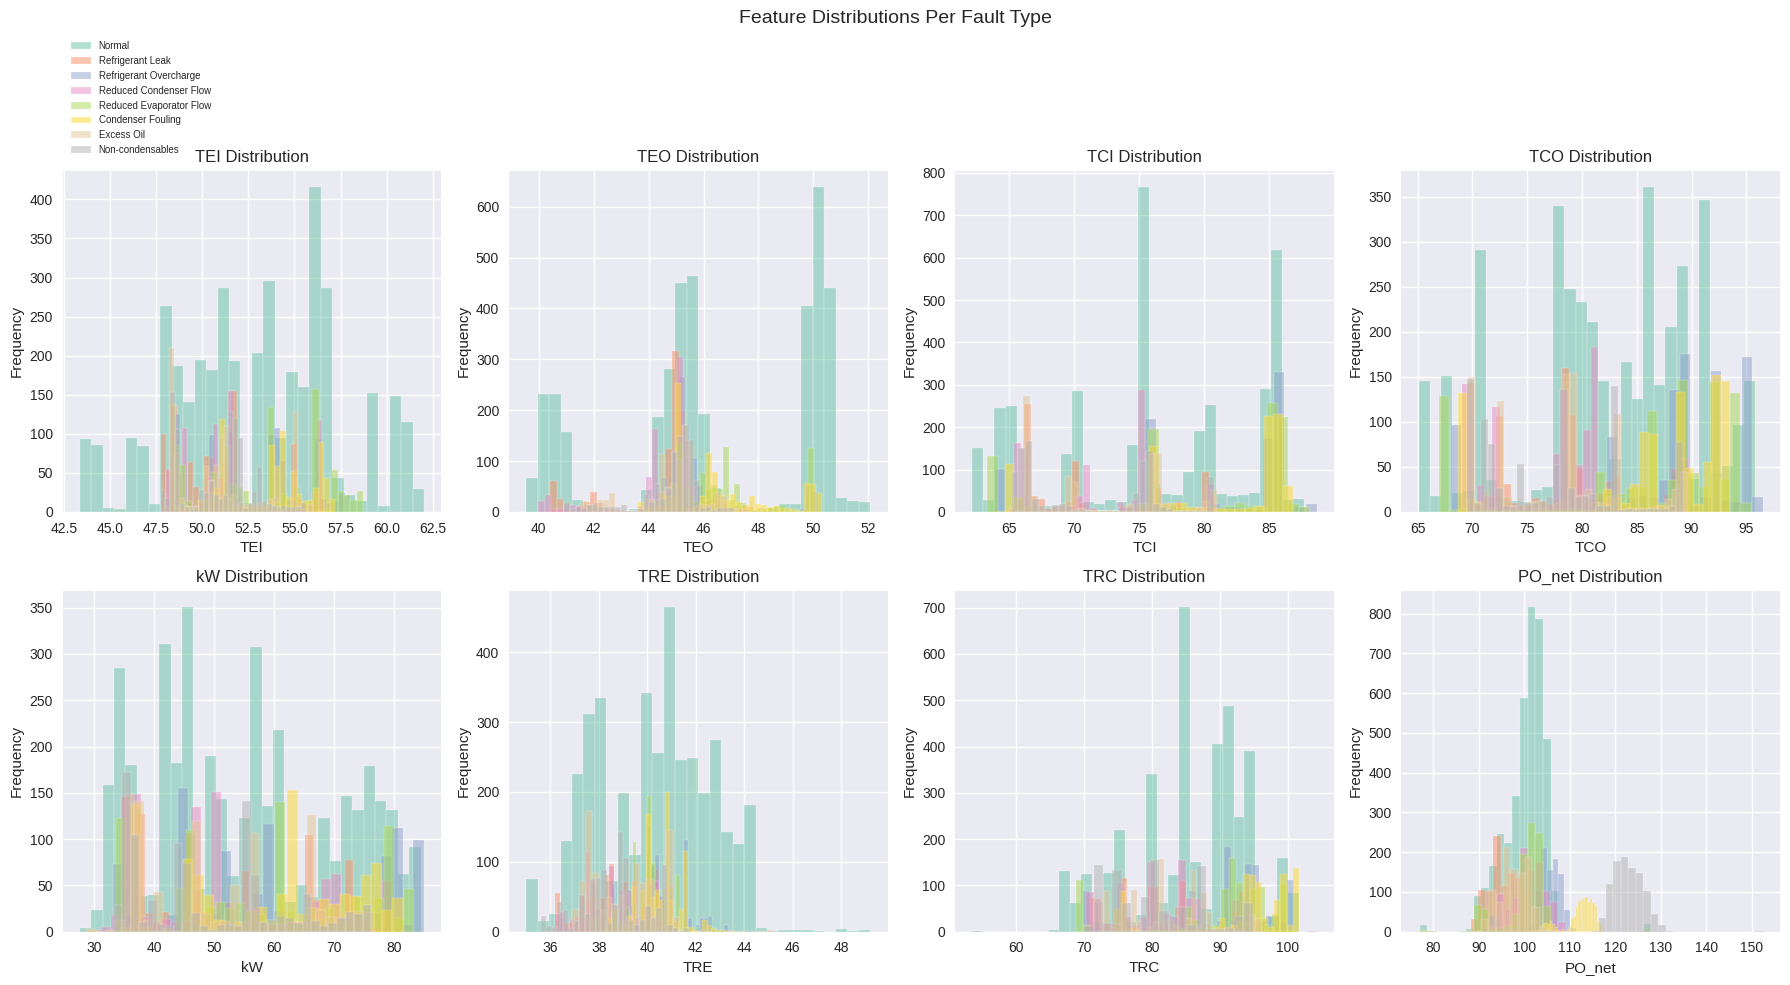

In [ ]:
print("=" * 50)
print("STEP 2 — FEATURE DISTRIBUTIONS PER FAULT")
print("=" * 50)

# Plot key features across fault types
key_features = ['TEI', 'TEO', 'TCI', 'TCO',
                'kW', 'TRE', 'TRC', 'PO_net']
colors = plt.cm.Set2(np.linspace(0, 1, len(fault_map)))

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    for j, (label, name) in enumerate(fault_map.items()):
        subset = df[df['label'] == label][feat]
        ax.hist(subset, bins=30, alpha=0.5,
                label=name, color=colors[j],
                edgecolor='white')
    ax.set_title(f'{feat} Distribution')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')

axes[0].legend(bbox_to_anchor=(0, 1.02),
               loc='lower left', fontsize=7)
plt.suptitle('Feature Distributions Per Fault Type',
             fontsize=14)
plt.tight_layout()
plt.show()

STEP 3 — BOXPLOTS PER FAULT TYPE


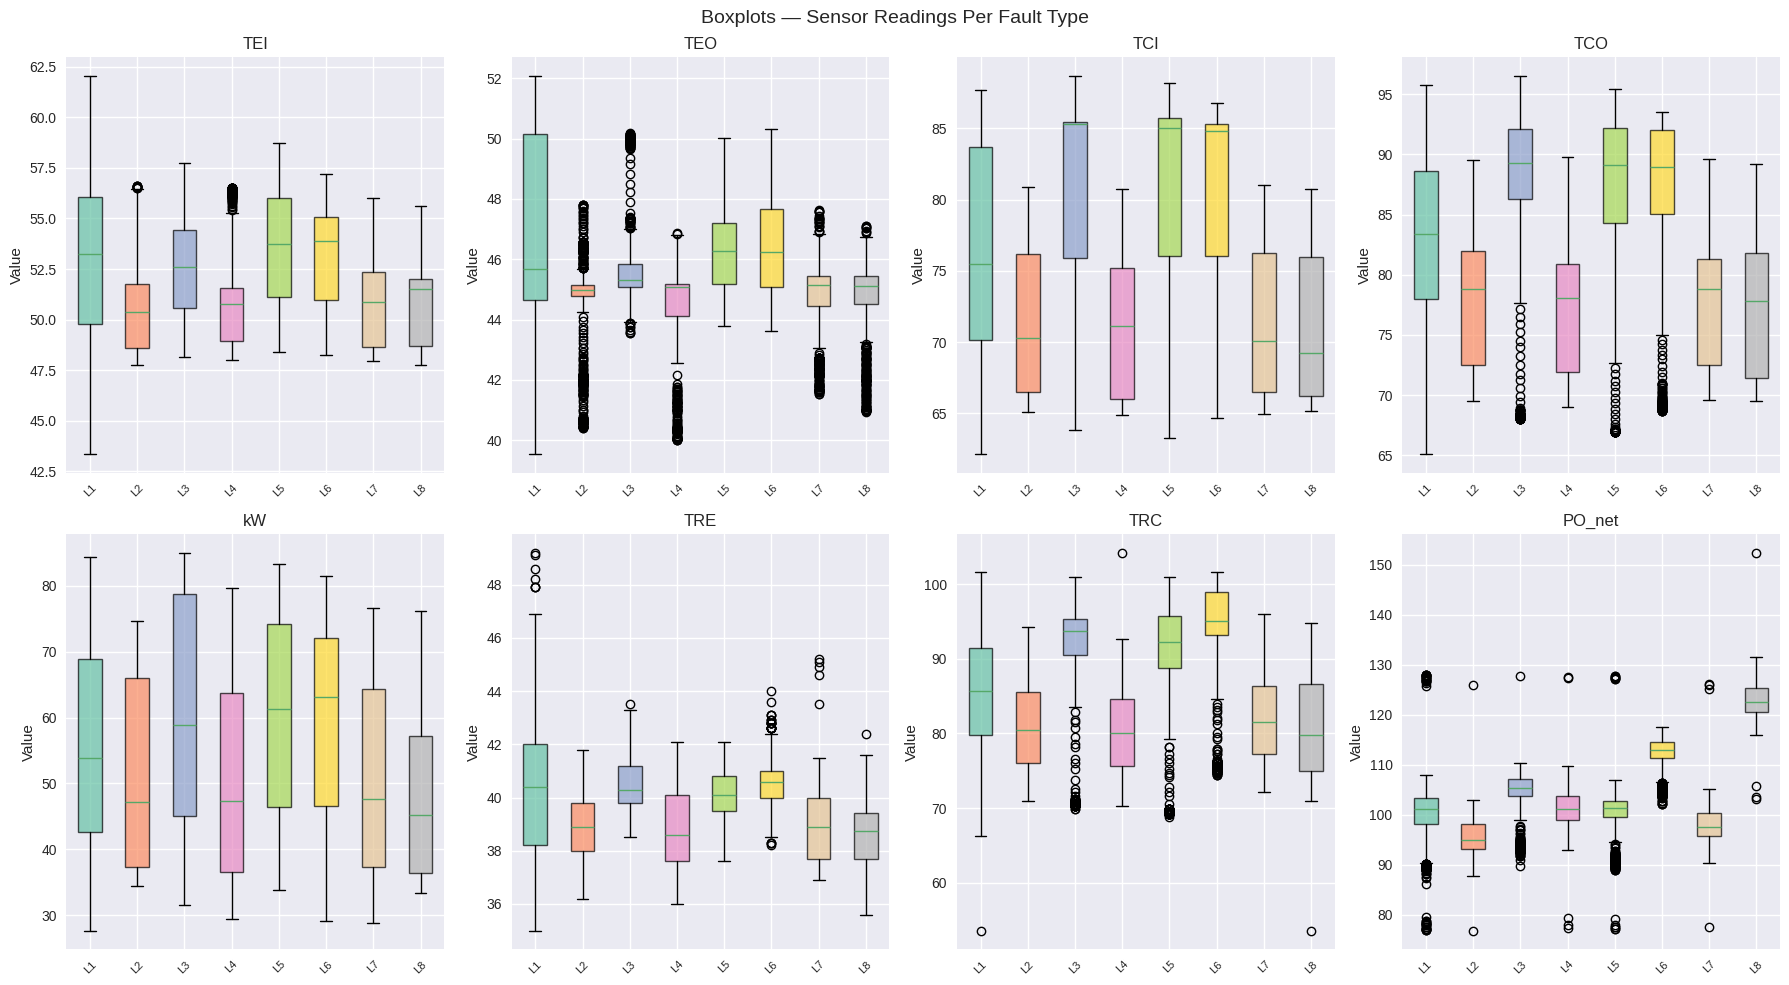

In [ ]:
print("=" * 50)
print("STEP 3 — BOXPLOTS PER FAULT TYPE")
print("=" * 50)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax   = axes[i]
    data = [df[df['label'] == label][feat].values
            for label in sorted(fault_map.keys())]
    bp   = ax.boxplot(data, patch_artist=True)

    colors_bp = plt.cm.Set2(
        np.linspace(0, 1, len(fault_map)))
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(f'{feat}')
    ax.set_xticklabels(
        [f'L{l}' for l in sorted(fault_map.keys())],
        rotation=45, fontsize=8)
    ax.set_ylabel('Value')

plt.suptitle('Boxplots — Sensor Readings Per Fault Type',
             fontsize=14)
plt.tight_layout()
plt.show()

STEP 4 — CORRELATION ANALYSIS


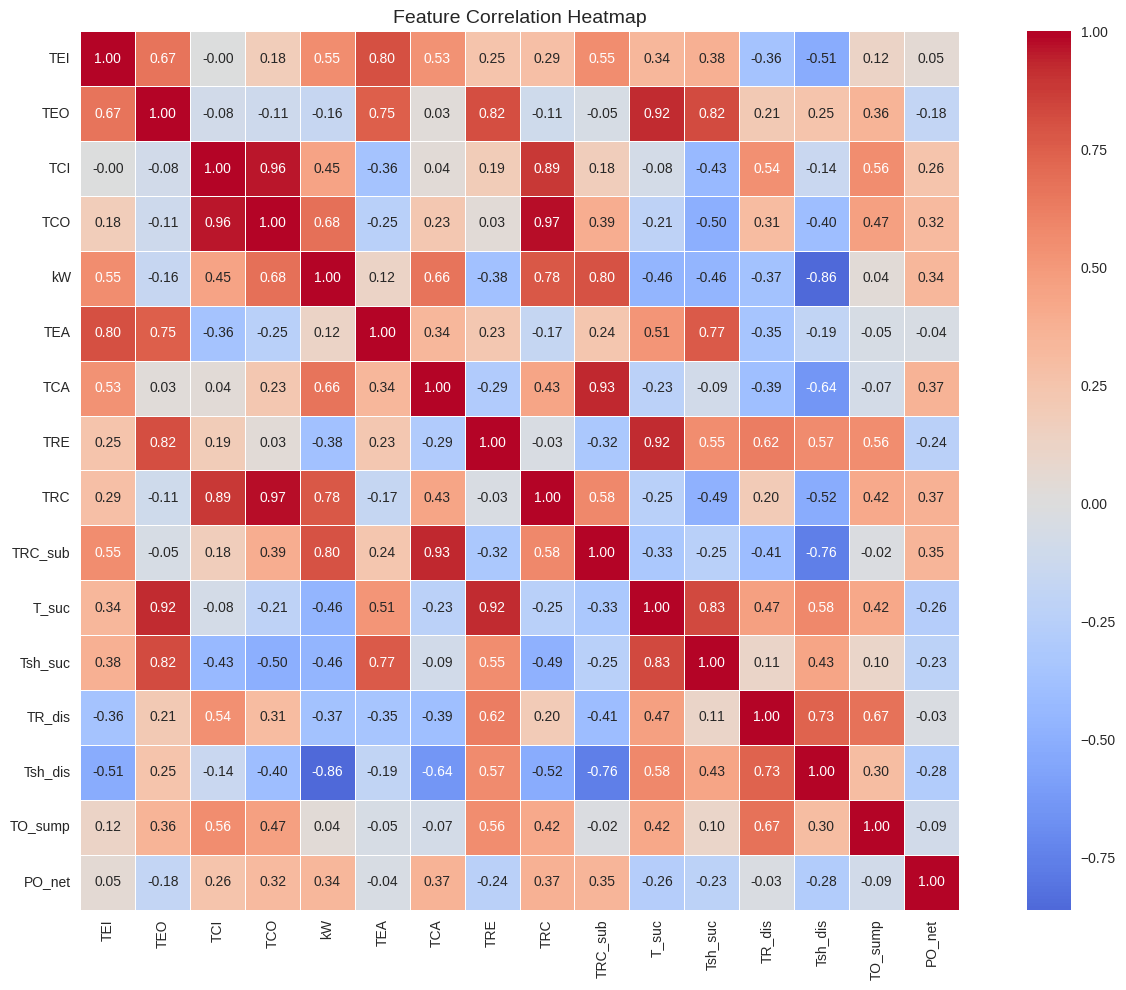


Top correlations (absolute value > 0.7):
  TEO        ↔ TRE        : 0.815
  TEO        ↔ T_suc      : 0.924
  TEO        ↔ Tsh_suc    : 0.820
  TCI        ↔ TCO        : 0.957
  TCI        ↔ TRC        : 0.890
  TCO        ↔ TRC        : 0.973
  TEA        ↔ TEI        : 0.804
  TEA        ↔ TEO        : 0.746
  TEA        ↔ Tsh_suc    : 0.767
  TCA        ↔ TRC_sub    : 0.929
  TRE        ↔ T_suc      : 0.921
  TRC        ↔ kW         : 0.780
  TRC_sub    ↔ kW         : 0.802
  TRC_sub    ↔ Tsh_dis    : 0.755
  T_suc      ↔ Tsh_suc    : 0.831
  TR_dis     ↔ Tsh_dis    : 0.734
  Tsh_dis    ↔ kW         : 0.860


In [ ]:
print("=" * 50)
print("STEP 4 — CORRELATION ANALYSIS")
print("=" * 50)

corr = df[feature_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop correlations (absolute value > 0.7):")
for col1 in feature_cols:
    for col2 in feature_cols:
        if col1 < col2:
            corr_val = abs(corr.loc[col1, col2])
            if corr_val > 0.7:
                print(f"  {col1:10} ↔ {col2:10} : "
                      f"{corr_val:.3f}")

STEP 5 — PAIRPLOT KEY FEATURES


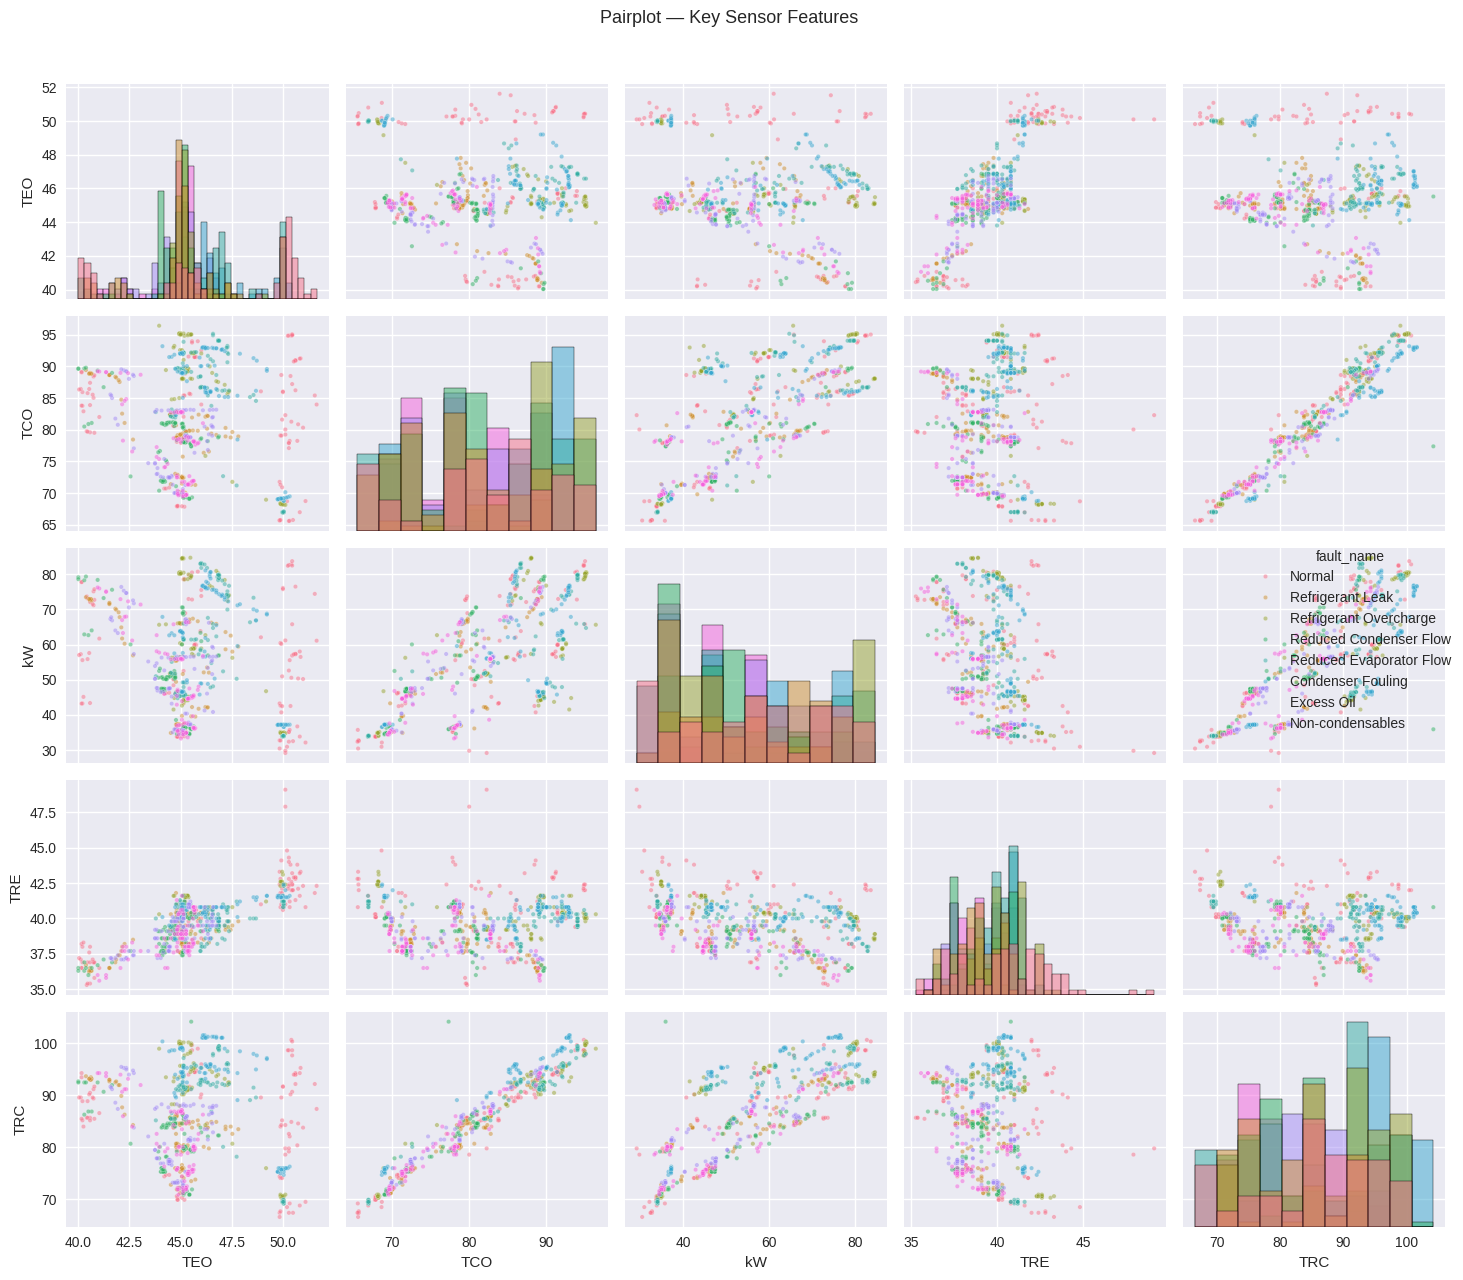

In [ ]:
print("=" * 50)
print("STEP 5 — PAIRPLOT KEY FEATURES")
print("=" * 50)

# Use subset for faster plotting
plot_features = ['TEO', 'TCO', 'kW', 'TRE',
                 'TRC', 'fault_name']
sample = df.groupby('label').apply(
    lambda x: x.sample(min(100, len(x)), random_state=42)
).reset_index(drop=True)

sns.pairplot(sample[plot_features],
             hue='fault_name',
             plot_kws={'alpha': 0.5, 's': 10},
             diag_kind='hist')
plt.suptitle('Pairplot — Key Sensor Features',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

STEP 6 — MEAN SENSOR VALUES PER FAULT


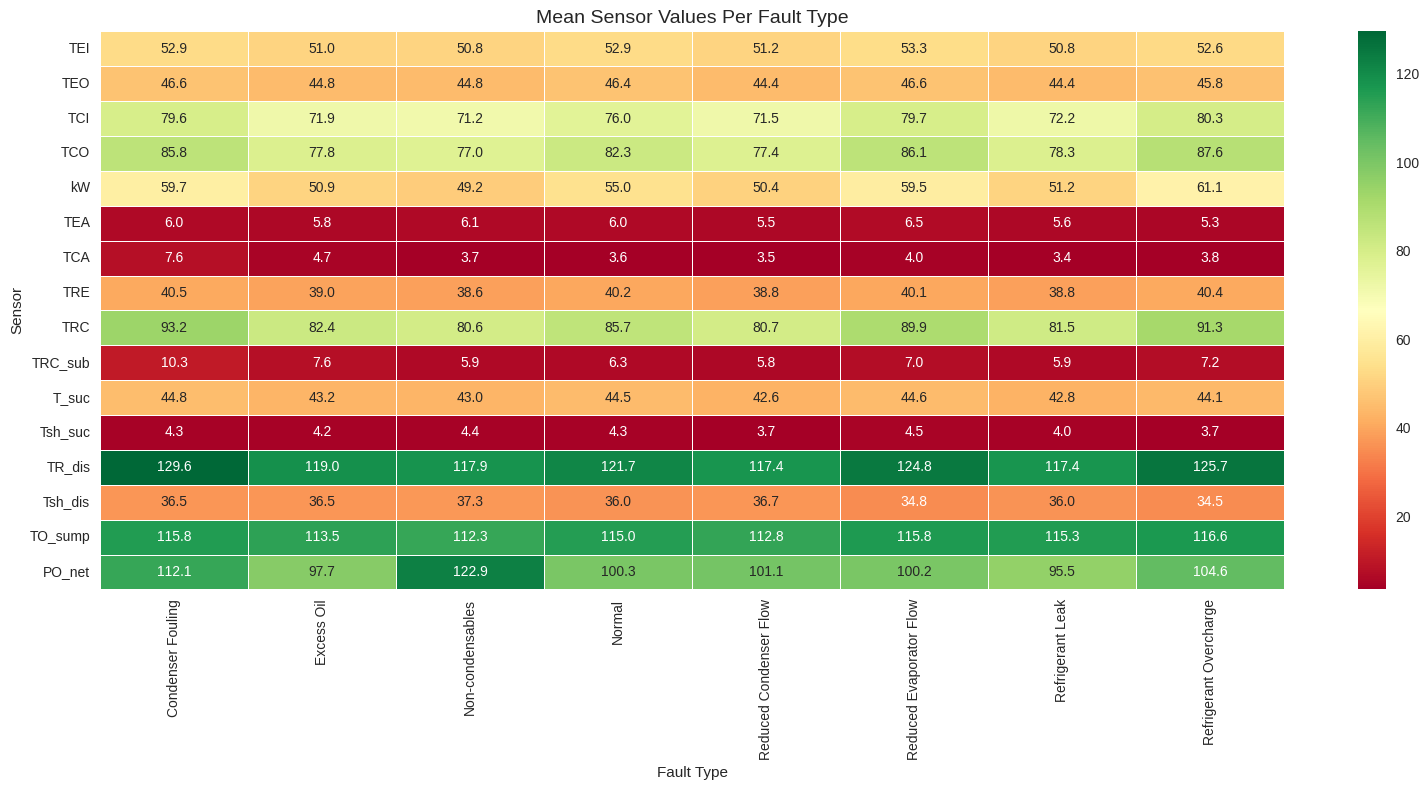


Mean values table:
fault_name  Condenser Fouling  Excess Oil  Non-condensables   Normal  Reduced Condenser Flow  Reduced Evaporator Flow  Refrigerant Leak  Refrigerant Overcharge
TEI                   52.9483     51.0364           50.8107  52.9402                 51.1747                  53.3120           50.7813                 52.5638
TEO                   46.5866     44.7988           44.7724  46.3761                 44.4133                  46.5821           44.4474                 45.8088
TCI                   79.6487     71.8941           71.2232  76.0281                 71.5151                  79.6793           72.2258                 80.2605
TCO                   85.8498     77.8474           77.0211  82.3161                 77.4123                  86.0866           78.2570                 87.6228
kW                    59.6540     50.9000           49.2309  55.0142                 50.3751                  59.4554           51.1766                 61.1247
TEA                 

In [ ]:
print("=" * 50)
print("STEP 6 — MEAN SENSOR VALUES PER FAULT")
print("=" * 50)

mean_by_fault = df.groupby('fault_name')[feature_cols]\
                   .mean()

plt.figure(figsize=(16, 8))
sns.heatmap(mean_by_fault.T,
            annot=True, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5)
plt.title('Mean Sensor Values Per Fault Type',
          fontsize=14)
plt.xlabel('Fault Type')
plt.ylabel('Sensor')
plt.tight_layout()
plt.show()

print("\nMean values table:")
print(mean_by_fault.T.to_string())

STEP 7 — NORMAL vs FAULTY COMPARISON
         Normal Mean  Faulty Mean  Difference %
TCA           3.6310       4.3900       20.8900
TRC_sub       6.2610       7.1050       13.4800
PO_net      100.3320     104.8720        4.5200
TEA           6.0150       5.7980       -3.6100
Tsh_suc       4.2600       4.1240       -3.2000
TEO          46.3760      45.3440       -2.2200
TEI          52.9400      51.8040       -2.1500
T_suc        44.5120      43.5830       -2.0900
TRE          40.2490      39.4600       -1.9600
TCI          76.0280      75.2070       -1.0800
TCO          82.3160      81.4420       -1.0600
kW           55.0140      54.5600       -0.8300
TO_sump     114.9890     114.5920       -0.3400
Tsh_dis      35.9770      36.0380        0.1700
TRC          85.6910      85.6540       -0.0400
TR_dis      121.6790     121.6810        0.0000


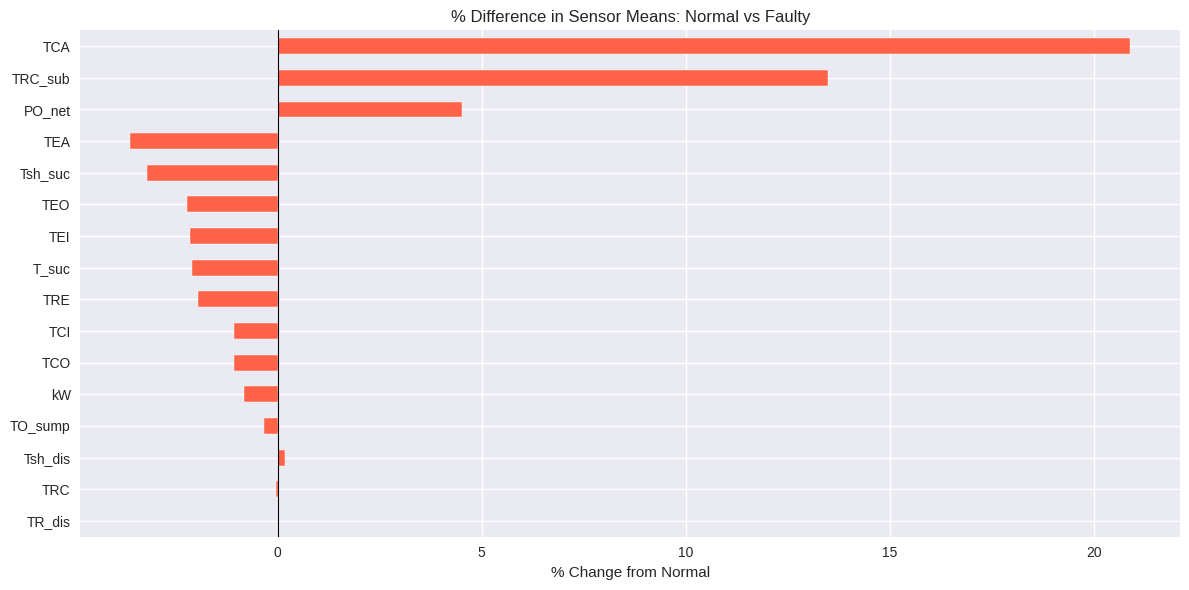

In [ ]:
print("=" * 50)
print("STEP 7 — NORMAL vs FAULTY COMPARISON")
print("=" * 50)

normal = df[df['binary_label'] == 0][feature_cols].mean()
faulty = df[df['binary_label'] == 1][feature_cols].mean()
diff   = ((faulty - normal) / normal * 100).round(2)

comparison = pd.DataFrame({
    'Normal Mean' : normal.round(3),
    'Faulty Mean' : faulty.round(3),
    'Difference %': diff
}).sort_values('Difference %', key=abs, ascending=False)

print(comparison.to_string())

# Visualize
plt.figure(figsize=(12, 6))
colors_bar = ['tomato' if abs(v) > 5
              else 'steelblue'
              for v in diff.sort_values(key=abs,
                                        ascending=False)]
diff.sort_values(key=abs, ascending=True)\
    .plot(kind='barh', color='tomato', edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('% Difference in Sensor Means: '
          'Normal vs Faulty')
plt.xlabel('% Change from Normal')
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 50)
print("STEP 8 — DATA QUALITY SUMMARY")
print("=" * 50)

print(f"Total rows         : {len(df):,}")
print(f"Missing values     : {df.isnull().sum().sum()}")
print(f"Duplicate rows     : {df.duplicated().sum()}")
print(f"Feature columns    : {len(feature_cols)}")
print(f"\nLevel 1 (Binary):")
print(f"  Normal (0)       : "
      f"{(df['binary_label']==0).sum():,} rows")
print(f"  Faulty (1)       : "
      f"{(df['binary_label']==1).sum():,} rows")
print(f"\nLevel 2 (Multi-class):")
for label, name in fault_map.items():
    if label > 1:
        count = (df['fault_label'] == label).sum()
        print(f"  Label {label} ({name:25}): "
              f"{count:,} rows")

print("\n✅ EDA Complete!")

STEP 8 — DATA QUALITY SUMMARY
Total rows         : 11,000
Missing values     : 0
Duplicate rows     : 3
Feature columns    : 16

Level 1 (Binary):
  Normal (0)       : 4,000 rows
  Faulty (1)       : 7,000 rows

Level 2 (Multi-class):
  Label 2 (Refrigerant Leak         ): 1,000 rows
  Label 3 (Refrigerant Overcharge   ): 1,000 rows
  Label 4 (Reduced Condenser Flow   ): 1,000 rows
  Label 5 (Reduced Evaporator Flow  ): 1,000 rows
  Label 6 (Condenser Fouling        ): 1,000 rows
  Label 7 (Excess Oil               ): 1,000 rows
  Label 8 (Non-condensables         ): 1,000 rows

✅ EDA Complete!
